In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [17]:
LEARNING_RATE = 2e-5
TRAIN_PATH = '../../flower_dataset/train'
VAL_PATH = '../../flower_dataset/valid'
TEST_PATH = '../../flower_dataset/test'
BATCH_SIZE = 32
EPOCH = 50

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [19]:
class TransformerBlock(nn.Module): 
    def __init__(self, embed_dim=192, mlp_dim=768): 
        super().__init__() 
 
        self.layer1_norm = nn.LayerNorm(embed_dim) 
        self.mult_head_attention = nn.MultiheadAttention(
            embed_dim=embed_dim, 
            num_heads=3, 
            batch_first=True
        ) 
 
        self.layer2_norm = nn.LayerNorm(embed_dim) 
        self.mlp = nn.Sequential( 
            nn.Linear(embed_dim, mlp_dim), 
            nn.GELU(), 
            nn.Linear(mlp_dim, embed_dim) 
        ) 
 
    def layer_1(self, x): 
        residual = x

        x = self.layer1_norm(x) 
        att_residue, _ = self.mult_head_attention(x, x, x) 
 
        x = residual + att_residue

        return x 
 
    def layer_2(self, x): 
        residual = x

        x = self.layer2_norm(x) 
        mlp_residue = self.mlp(x) 
 
        x = residual + mlp_residue

        return x 
 
    def forward(self, x): 
        x = self.layer_1(x) 
        x = self.layer_2(x) 
 
        return x

In [20]:
class ViT(nn.Module): 
    def __init__(self, num_patches=196, embed_dim=192, mlp_dim=768, depth=4): 
        super().__init__() 
 
        self.patch = nn.Sequential( 
            nn.Conv2d(
                in_channels=3, 
                out_channels=embed_dim, 
                kernel_size=16, 
                stride=16
            ), 
            nn.Flatten(start_dim=2, end_dim=3) 
        ) 
 
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) 
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim)) 
 
        nn.init.trunc_normal_(self.cls_token, std=0.02) 
        nn.init.trunc_normal_(self.pos_embed, std=0.02) 
 
        self.transformer_blocks = nn.ModuleList()

        for i in range(depth):
            self.transformer_blocks.append(
                TransformerBlock(
                    embed_dim=embed_dim,
                    mlp_dim=mlp_dim
                )
            )

        self.classifier = nn.Linear(embed_dim, 102)
 
    def patch_embed(self, x): 
        x = self.patch(x) 
        x = x.permute(0, 2, 1) 
 
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1) 
 
        x = torch.cat((cls_tokens, x), dim=1) 
        x = x + self.pos_embed 
 
        return x 
 
    def transformer_encoder(self, x): 
        for block in self.transformer_blocks:
            x = block(x)

        return x
 
    def forward(self, x): 
        x = self.patch_embed(x) 
        x = self.transformer_encoder(x)

        x = x[:, 0]
        x = self.classifier(x)

        return x

In [21]:
model = ViT()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(EPOCH):
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    model.train()
        
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)    

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss_sum += loss.item()

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)


    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch}:Train Loss: {train_loss} | Val Loss: {val_loss}")
    

Epoch 0:Train Loss: 4.359208533930224 | Val Loss: 4.101094391196966
Epoch 1:Train Loss: 3.928104269412137 | Val Loss: 3.8141156174242496
Epoch 2:Train Loss: 3.6642479526904204 | Val Loss: 3.60108732432127
Epoch 3:Train Loss: 3.4582287100858466 | Val Loss: 3.4208043105900288
Epoch 4:Train Loss: 3.28622001825377 | Val Loss: 3.2866043988615274
Epoch 5:Train Loss: 3.1485324885494026 | Val Loss: 3.1738766226917505
Epoch 6:Train Loss: 3.0088187077248745 | Val Loss: 3.0586054157465696
Epoch 7:Train Loss: 2.8944484078606894 | Val Loss: 2.962881352752447
Epoch 8:Train Loss: 2.794987859652024 | Val Loss: 2.879822162911296
Epoch 9:Train Loss: 2.6910547507825746 | Val Loss: 2.807777864858508
Epoch 10:Train Loss: 2.598325480786405 | Val Loss: 2.7409096071496606
Epoch 11:Train Loss: 2.519822349844053 | Val Loss: 2.697973085567355
Epoch 12:Train Loss: 2.4363144063210305 | Val Loss: 2.629115551710129
Epoch 13:Train Loss: 2.3705950670464095 | Val Loss: 2.585217960178852
Epoch 14:Train Loss: 2.301030814

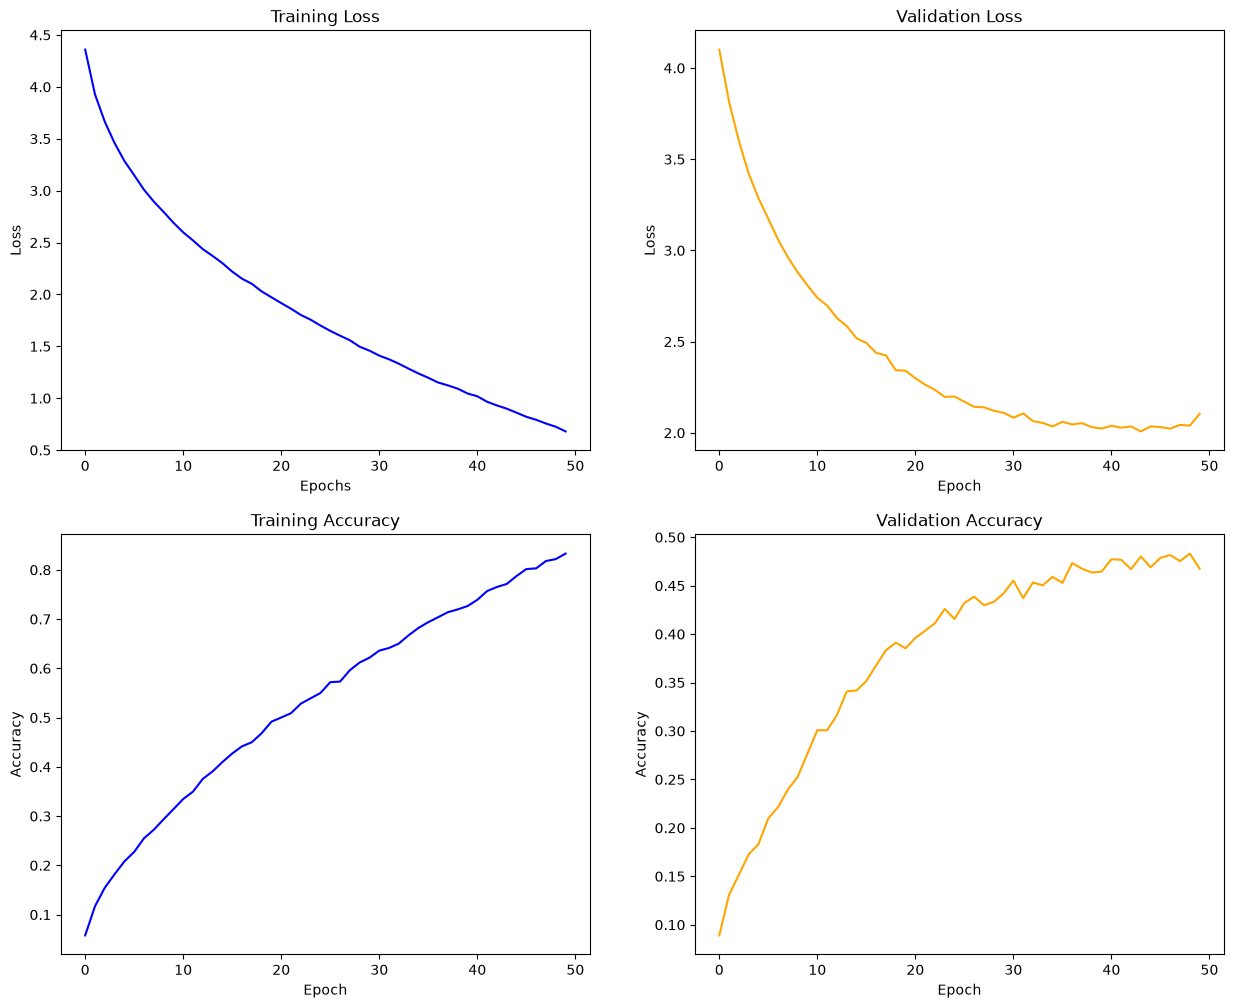

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_loss_list, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_loss_list, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_acc_list, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_acc_list, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()

In [23]:
model.eval()

correct = 0
samples = 0

preds = []
true = []


with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)

        preds.extend(predicted.tolist())
        true.extend(labels.tolist())

accuracy = correct/samples
print(accuracy)

0.4745347698334966
